In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from scipy.stats import norm
from scipy.stats import mannwhitneyu

from copy import deepcopy
import random


from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(0)



blue = '#0073B7'
yellow = '#FFD23F'
gray = '#7A7A7A'
purple = '#B05AA3'
green = '#00A651'
orange = '#F7941D'


blue_yellow = LinearSegmentedColormap.from_list(
    "blue_yellow", ["#0073B7", "#FFD23F"]
)


gray = '#C0C0C0'
purple = '#B05AA3'

gray_purple = LinearSegmentedColormap.from_list(
    "gray_purple",
    [gray , purple]
)

blue = '#00AEEF'
red = '#F15A2A'

In [2]:
from src.model import SSCNetwork
from src.utils.episode_generation_protocol import make_input, LatentSpace
from src.utils.general import get_ordered_indices, get_sample_from_num_swaps, get_cos_sim_torch, test_network, get_signal_to_noise_ratio
from src.network_parameters import network_parameters
from src.utils.plotting import compare_distributions_12

In [3]:
#network_parameters["regions"] = ["sen", "mtl_semantic", "mtl_sensory", "mtl", "ctx", "ctx_pointer_definition"]

#make network randomly project sensory input to obtain a wide distribution of selectivity in MTL-sensory
recording_parameters = {}
recording_parameters["regions"] = ["sen", "mtl_semantic", "mtl_sensory", "ctx", "mtl"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf

num_episodes = 10
input_params = {}
input_params["num_days"] = 1
input_params["day_length"] = 5 * num_episodes
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 2

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]
latent_specs["prob_list"] = [0.5/5 if i==j else 0.5/20 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)

In [4]:
def test_network(net, input_params, scrambled=False, sleep=False, print_rate=1):
  input, input_episodes, input_latents = make_input(**input_params)
  if scrambled:
    permutation = torch.randperm(net.sen_size)
  with torch.no_grad():
    for day in range(input_params["num_days"]):
      if day%print_rate == 0:
        print(day)
      if scrambled:
        net(input[day, :, permutation], debug=False)
      else:
        net(input[day], debug=False)
      if sleep:
        net.sleep()
  return input, input_episodes, input_latents, net

In [5]:

def episode_recall(net, ep, num_swaps):
    num_iterations = 10
    mtl_sensory_corrupted =  get_sample_from_num_swaps(ep[:net.mtl_sensory_size], num_swaps)
    mtl_0 = torch.zeros((net.mtl_size))
    mtl_0[:net.mtl_sensory_size] = mtl_sensory_corrupted
    mtl = mtl_0.clone()
    for iteration in range(num_iterations):
      mtl_hat = F.linear(net.mtl_mtl, mtl)
      mtl, _ = net.activation(mtl_hat, 'mtl')

    recall_sensory = get_cos_sim_torch(mtl[:net.mtl_sensory_size], ep[:net.mtl_sensory_size])
    recall_semantic = get_cos_sim_torch(mtl[net.mtl_sensory_size:], ep[net.mtl_sensory_size:])
    recall = get_cos_sim_torch(mtl, ep)
    return mtl_0, mtl, recall_sensory, recall_semantic, recall



def get_recalls(network, scrambled=False):
    num_trials = 10
    recalls = []
    recalls_semantic = []
    recalls_sensory = []
    for trial in range(num_trials):
        network.init_recordings(recording_parameters)
        network.frozen = False
        network.activity_recordings_rate = 1
        network.connectivity_recordings_rate = np.inf



        input, input_episodes, input_latents, network = test_network(
            network, input_params, scrambled, sleep=False, print_rate=50
        )

        for episode in torch.stack(network.activity_recordings["mtl"], axis=0):
            mtl_0, mtl, recall_sensory, recall_semantic, recall = episode_recall(network, episode, num_swaps=5)
            recalls.append(recall)
            recalls_semantic.append(recall_semantic)
            recalls_sensory.append(recall_sensory)

    return recalls, recalls_sensory, recalls_semantic

In [6]:
network = torch.load("checkpoints/network_3_B.pt", weights_only=False)

In [7]:
recalls_intact = get_recalls(network)
recalls_scrambled = get_recalls(network, scrambled=True)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


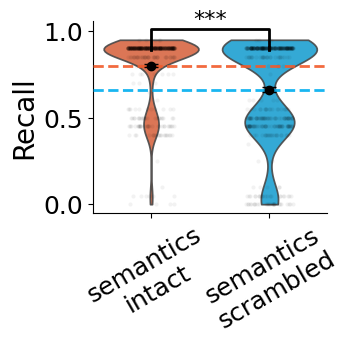

In [8]:
dist1 = ('semantics\nintact', recalls_intact[1])
dist2 = ('semantics\nscrambled', recalls_scrambled[1])

palette = {
    "semantics\nintact": red, 
    "semantics\nscrambled": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("Recall", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 0.5, 1], fontsize=18)
plt.tight_layout()
sns.despine()


plt.savefig('Figures_SVG/7c.svg', dpi=300, transparent=True)

In [9]:
def get_recalls_for_noise(network, stored_num_swaps, scrambled=False, num_trials=10):
    recalls = []
    recalls_semantic = []
    recalls_sensory = []
    for trial in range(num_trials):
        network.init_recordings(recording_parameters)
        network.frozen = False
        network.activity_recordings_rate = 1
        network.connectivity_recordings_rate = np.inf

        input_params_local = deepcopy(input_params)
        input_params_local["num_swaps"] = stored_num_swaps

        input, input_episodes, input_latents, network = test_network(
            network, input_params_local, scrambled, sleep=False, print_rate=50
        )

        for episode in torch.stack(network.activity_recordings["mtl"], axis=0):
            mtl_0, mtl, recall_sensory, recall_semantic, recall = episode_recall(
                network, episode, num_swaps=0
            )
            recalls.append(recall)
            recalls_semantic.append(recall_semantic)
            recalls_sensory.append(recall_sensory)

    return recalls, recalls_sensory, recalls_semantic


In [10]:
import multiprocessing

shared_num_seeds = 10
shared_seeds = list(range(shared_num_seeds))
shared_noise_levels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

network = torch.load("checkpoints/network_3_B.pt", weights_only=False)
shared_snr_levels = [
    get_signal_to_noise_ratio(level, network, region="mtl_sensory")
    for level in shared_noise_levels
]

recall_sweep_params = {}
recall_sweep_params["num_seeds"] = shared_num_seeds
recall_sweep_params["num_cpu"] = 8
recall_sweep_params["stored_num_swaps_values"] = shared_noise_levels
recall_sweep_params["num_trials"] = 10


def run_recall_noise_point(seed, stored_num_swaps, scrambled):
    seed_everything(seed)
    network = torch.load("checkpoints/network_3_B.pt", weights_only=False)
    recalls = get_recalls_for_noise(
        network,
        stored_num_swaps=stored_num_swaps,
        scrambled=scrambled,
        num_trials=recall_sweep_params["num_trials"],
    )
    return {
        "seed": seed,
        "stored_num_swaps": stored_num_swaps,
        "condition": "scrambled" if scrambled else "intact",
        "mean_recall": float(np.mean(recalls[1])),
        "within_episode_std": float(np.std(recalls[1])),
    }


experiment_params = [
    (seed, stored_num_swaps, scrambled)
    for scrambled in [False, True]
    for stored_num_swaps in recall_sweep_params["stored_num_swaps_values"]
    for seed in shared_seeds
]

ctx = multiprocessing.get_context("fork")
with ctx.Pool(processes=recall_sweep_params["num_cpu"]) as pool:
    recall_noise_results = pool.starmap(run_recall_noise_point, experiment_params)


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


00000000







0
00
0
0

0
0
0
00
0

0
0
0
00

00

0
00

0
0
0
000


0
0
0
0
0
000


00
0

00

00

0
00

000


00

00

0
0
0
0
00

0
00

00

0
0
00

00

0
0
0
000


0
0
0
0
0
00

0
00

0
0
0
0
00

0
0
00

0
0
0
0
0
00

0
0
0
00

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
00
00


0
000

0

0
00

0
00

0
00

00

0
0000



0
0
0
0
0
0
000


0
0
0
0
0000
0



0
0
00

00

000


0
0
0
0
0
0
0
0
0
000


00

0
0
0
00

0
00

0
0
0
00

0
0
00

0
0
000


0
0
0
0
0
0
0
0
0
00

0
0
00

0
00

0
0
0
0
0
00

0
0
0
0
0
00

0
00

0
0
0
00

0
00

0
0
0
0
00

0
0
0
0
0
00

00
0

0
0
0
0
00

00

0
0
0
00

0
0
0
0
0
00

0
0
0
0
0
0
0
0
0
0
0
0
0
0
00

0
0
0
0
0
0
0
0
00

00

0
0
0
00

00

0
0
0
0
00

0
0
0
0
0
0
00

00

0
0
0
0
0
0
0
00

0
0
00

0
0
00

0
0
0
0
0
00
0

0
0
0
0
0
00

0
0
0
00

0
00

0
0
0
0
0
0
0
0
0
0
0
0
0
000


0
0
0
0
0
00

0
0
0
0
0
00
0

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
00

00

0
0
0
0
0
0
00

0
0
0
0
0
0
00

0
0
0
0
00

0
0
0
0
0
0
00

00

0
0
0
0
00

0
0
0
0
0
0
0
00
0



/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


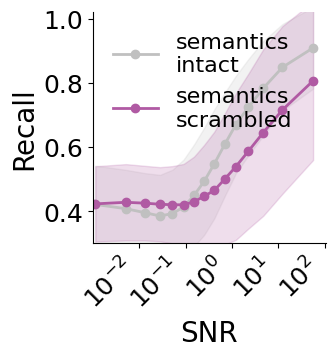

In [12]:
recall_noise_df = pd.DataFrame(recall_noise_results)

recall_noise_summary = (
    recall_noise_df.groupby(["condition", "stored_num_swaps"])
    .agg(
        mean_recall_mean=("mean_recall", "mean"),
        within_episode_std_mean=("within_episode_std", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(3, 3))

network = torch.load("checkpoints/network_3_B.pt", weights_only=False)
noise_to_snr = {
    int(level): float(get_signal_to_noise_ratio(level, network, region="mtl_sensory"))
    for level in shared_noise_levels
}

for condition, color, label in [
    ("intact", gray, "semantics\nintact"),
    ("scrambled", purple, "semantics\nscrambled"),
]:
    condition_df = recall_noise_summary[recall_noise_summary["condition"] == condition].copy()
    x_num_swaps = condition_df["stored_num_swaps"].to_numpy()
    x = np.array([noise_to_snr[int(level)] for level in x_num_swaps], dtype=float)
    mean_curve = condition_df["mean_recall_mean"].to_numpy()
    std_curve = condition_df["within_episode_std_mean"].to_numpy()
    ax.plot(x, mean_curve, marker='o', color=color, linewidth=2, label=label)
    ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.2)

ax.set_xlabel("SNR", fontsize=20)
ax.set_ylabel("Recall", fontsize=20)
ax.set_xscale("log")
shared_lower = 1e-3
shared_upper = max(float(np.max(shared_snr_levels)), 1e2) * 1.05
decade_ticks = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylim(0.3, 1.02)
ax.legend(frameon=False, fontsize=16)
sns.despine()
plt.savefig('Figures_SVG/7b.svg', dpi=300, transparent=True)
plt.show()


# Blocked vs interleaved

In [131]:
seed_everything(0)


recording_parameters = {}
recording_parameters["regions"] = ["mtl_sensory", "ctx"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf


input_params = {}
input_params["num_days"] = 10
input_params["day_length"] = 50
input_params["mean_duration"] = 1
input_params["fixed_duration"] = True
input_params["num_swaps"] = 8

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]

In [152]:
latent_specs["prob_list"] = [0.2 if i==0 else 0 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)

network = SSCNetwork(network_parameters, recording_parameters)
input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)


prototype_A = torch.zeros(latent_specs["dims"][0], network.mtl_sensory_size)
replayed_A =  torch.zeros(latent_specs["dims"][0], input_params["num_days"]*network.sleep_duration_A, network.mtl_sensory_size)
prototype_B = torch.zeros(latent_specs["dims"][1], network.mtl_sensory_size)
replayed_B =  torch.zeros(latent_specs["dims"][0],  input_params["num_days"]*network.sleep_duration_A, network.mtl_sensory_size)

replayed_A[0] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
prototype_A[0] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
network.awake_indices = []
network.sleep_indices_A = []

0
50
100
150


In [ ]:
for k in range(1, 5):
    latent_specs["prob_list"] = [0.2 if i==k else 0 for i in range(5) for j in range(5)]
    input_params["latent_space"] = LatentSpace(**latent_specs)
    input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)
    replayed_A[k] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
    prototype_A[k] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
    network.awake_indices = []
    network.sleep_indices_A = []


for k in range(5):
    latent_specs["prob_list"] = [0.2 if j==k else 0 for i in range(5) for j in range(5)]
    input_params["latent_space"] = LatentSpace(**latent_specs)
    input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)
    replayed_B[k] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
    prototype_B[k] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
    network.awake_indices = []
    network.sleep_indices_A = []


0


In [134]:
def get_max_overlap(replayed, prototpyes):
    cos_sims = [get_cos_sim_torch(replayed, prototype) for prototype in prototpyes]
    max_sim = torch.max(torch.stack(cos_sims, dim=0))
    return max_sim.item()

In [135]:

prototypes = torch.concat([prototype_A, prototype_B], axis=0)
max_overlaps_blocked = []
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[0]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[1]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[2]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[3]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[4]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[0]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[1]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[2]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[3]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[4]])

In [136]:
recording_parameters = {}
recording_parameters["regions"] = ["mtl_semantic", "mtl_sensory", "ctx"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf


input_params = {}
input_params["num_days"] = 200
input_params["day_length"] = 80
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 8

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]

In [137]:
latent_specs["prob_list"] = [0.5/5 if i==j else 0.5/20 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)
input, input_episodes, input_latents, network = test_network(network, input_params, sleep=False, print_rate=50)


0
50
100
150


In [138]:
X_ctx = torch.stack(network.activity_recordings["ctx"], dim=0)[network.awake_indices][-100*input_params["day_length"]:]

X_latent_A = F.one_hot(input_latents[-100:, :, 0].long(), num_classes=latent_specs["dims"][0])
X_latent_B = F.one_hot(input_latents[-100:, :, 1].long(), num_classes=latent_specs["dims"][1])
X_latent_AB = torch.cat((X_latent_A, X_latent_B), axis=2)


network.selectivity_ctx, network.ordered_indices_ctx  = get_ordered_indices(X_ctx, X_latent_AB, assembly_size=10)

In [140]:
sel_blocked = network.selectivity_ctx.max(axis=1)[0]

In [141]:
input_params["num_days"] = 100
input_params["day_length"] = 50
input_params["mean_duration"] = 1
latent_specs["prob_list"] = [1/25 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)
network = SSCNetwork(network_parameters, recording_parameters)
input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)

0
50


In [142]:
replayed_interleaved = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
max_overlaps_interleaved = [get_max_overlap(replayed, prototypes) for replayed in replayed_interleaved]

/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


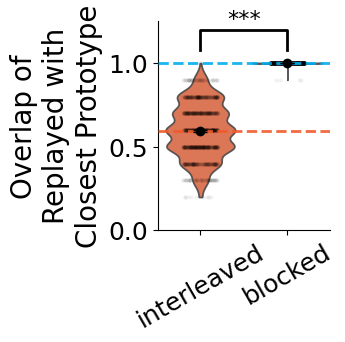

In [143]:
dist1 = ('interleaved', max_overlaps_interleaved)
dist2 = ('blocked', max_overlaps_blocked)

palette = {
    "interleaved": red,   # light blue
    "blocked": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("Overlap of\nReplayed with\nClosest Prototype", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 0.5, 1], fontsize=18)
plt.tight_layout()
sns.despine()


#plt.savefig('Figures_SVG/7d.svg', dpi=300, transparent=True)

In [144]:
recording_parameters = {}
recording_parameters["regions"] = ["mtl_semantic", "mtl_sensory", "ctx"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf


input_params = {}
input_params["num_days"] = 200
input_params["day_length"] = 80
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 8

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]

In [145]:
latent_specs["prob_list"] = [0.5/5 if i==j else 0.5/20 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)
input, input_episodes, input_latents, network = test_network(network, input_params, sleep=False,print_rate=50)


0
50
100
150


In [146]:
X_ctx = torch.stack(network.activity_recordings["ctx"], dim=0)[network.awake_indices][-100*input_params["day_length"]:]

X_latent_A = F.one_hot(input_latents[-100:, :, 0].long(), num_classes=latent_specs["dims"][0])
X_latent_B = F.one_hot(input_latents[-100:, :, 1].long(), num_classes=latent_specs["dims"][1])
X_latent_AB = torch.cat((X_latent_A, X_latent_B), axis=2)


network.selectivity_ctx, network.ordered_indices_ctx  = get_ordered_indices(X_ctx, X_latent_AB, assembly_size=10)

In [147]:
sel_interleaved = network.selectivity_ctx.max(axis=1)[0]

/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


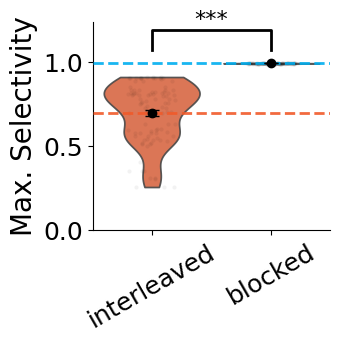

In [148]:
dist1 = ('interleaved', sel_interleaved[:100])
dist2 = ('blocked', sel_blocked[:100])

palette = {
    "interleaved": red,   # light blue
    "blocked": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("Max. Selectivity", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 0.5, 1], fontsize=18)
plt.tight_layout()
sns.despine()


#plt.savefig('Figures_SVG/7d.svg', dpi=300, transparent=True)

In [3]:
# Blocked vs interleaved selectivity sweep across SNR
import multiprocessing
from Figure_7_recall_blocked_utils import run_blocked_interleaved_noise_point


In [4]:
blocked_interleaved_sweep_params = {}
blocked_interleaved_sweep_params["num_seeds"] = 1
blocked_interleaved_sweep_params["num_cpu"] = 8
blocked_interleaved_sweep_params["num_swaps_values"] = (
    shared_noise_levels if "shared_noise_levels" in globals() else [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
)
blocked_interleaved_seeds = list(range(blocked_interleaved_sweep_params["num_seeds"]))

reference_recording_parameters = {
    "regions": [],
    "rate_activity": np.inf,
    "connections": [],
    "rate_connectivity": np.inf,
}
reference_network = SSCNetwork(network_parameters, reference_recording_parameters)
blocked_interleaved_snr_by_noise = {
    int(level): float(get_signal_to_noise_ratio(level, reference_network, region="mtl_sensory"))
    for level in blocked_interleaved_sweep_params["num_swaps_values"]
}

experiment_params = [
    (seed, num_swaps, network_parameters)
    for num_swaps in blocked_interleaved_sweep_params["num_swaps_values"]
    for seed in blocked_interleaved_seeds
]

ctx = multiprocessing.get_context("fork")
with ctx.Pool(processes=blocked_interleaved_sweep_params["num_cpu"]) as pool:
    blocked_interleaved_noise_results = pool.starmap(
        run_blocked_interleaved_noise_point,
        experiment_params,
    )


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


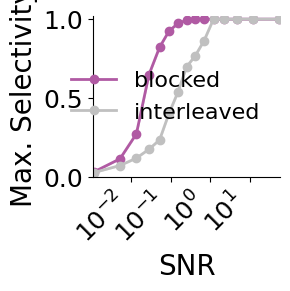

In [8]:
blocked_interleaved_selectivity_rows = []
for result in blocked_interleaved_noise_results:
    blocked_interleaved_selectivity_rows.append(
        {
            "condition": "blocked",
            "num_swaps": result["num_swaps"],
            "seed": result["seed"],
            "mean_selectivity": result["mean_selectivity_blocked"],
        }
    )
    blocked_interleaved_selectivity_rows.append(
        {
            "condition": "interleaved",
            "num_swaps": result["num_swaps"],
            "seed": result["seed"],
            "mean_selectivity": result["mean_selectivity_interleaved"],
        }
    )

blocked_interleaved_selectivity_df = pd.DataFrame(blocked_interleaved_selectivity_rows)
blocked_interleaved_selectivity_summary = (
    blocked_interleaved_selectivity_df.groupby(["condition", "num_swaps"])
    .agg(
        mean_selectivity=("mean_selectivity", "mean"),
        std_selectivity=("mean_selectivity", "std"),
    )
    .reset_index()
)
blocked_interleaved_selectivity_summary["std_selectivity"] = (
    blocked_interleaved_selectivity_summary["std_selectivity"].fillna(0.0)
)

fig, ax = plt.subplots(figsize=(3, 3))

for condition, color, label in [
    ("blocked", purple, "blocked"),
    ("interleaved", gray, "interleaved"),
]:
    condition_df = blocked_interleaved_selectivity_summary[
        blocked_interleaved_selectivity_summary["condition"] == condition
    ].copy()
    condition_df = condition_df.sort_values("num_swaps")
    x = np.array(
        [blocked_interleaved_snr_by_noise[int(level)] for level in condition_df["num_swaps"]],
        dtype=float,
    )
    y = condition_df["mean_selectivity"].to_numpy()
    yerr = condition_df["std_selectivity"].to_numpy()
    ax.plot(x, y, marker="o", linewidth=2, color=color, label=label)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2)

ax.set_xlabel("SNR", fontsize=20)
ax.set_ylabel("Max. Selectivity", fontsize=20)
ax.set_xscale("log")
shared_lower = max(min(blocked_interleaved_snr_by_noise.values()) * 0.95, 1e-3)
shared_upper = max(blocked_interleaved_snr_by_noise.values()) * 1.05
decade_ticks = np.array([1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(
    lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else ""
)
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(frameon=False, fontsize=16)
sns.despine()
plt.tight_layout()
plt.savefig("Figures_SVG/7d2.svg", dpi=300, transparent=True)
plt.show()
